# 04 — v2: Elasticidade de preço & otimização de prêmio

Do **custo** (v1) ao **preço** (v2): estimar a sensibilidade da retenção ao preço e otimizar o prêmio comercial no trade-off **lucro × retenção**. Base ES (painel 2015–2018, com `Premium` e renovações), importando o motor `src/pricing`.

> **Honestidade primeiro:** elasticidade a partir de dado observacional sofre **endogeneidade** (o preço não foi aleatorizado). Tratamos como *demonstração de método*; a otimização irrestrita é apresentada como **cautionary tale**, não como recomendação.

In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, mean_tweedie_deviance

ROOT = None
for base in [pathlib.Path('.'), pathlib.Path('..')]:
    if (base / 'src' / 'pricing').exists():
        ROOT = base.resolve(); break
sys.path.insert(0, str(ROOT))

from src.pricing.es_data import build_modeling_frame, ES_NUMERIC, ES_CATEGORICAL
from src.pricing.es_models import (build_cost_model, build_retention_model,
    build_retention_gbm, RETENTION_NUMERIC, optimize_premium)

plt.rcParams['figure.figsize'] = (8, 4)
df = build_modeling_frame()
obs = df[df['observed_outcome']].copy()
tr = obs[obs['renewal_year'] <= 2016]
te = obs[obs['renewal_year'] == 2017]
print('treino', len(tr), '| teste', len(te), '| renovacao media', round(obs['renewed'].mean(), 3))

treino 35987 | teste 30871 | renovacao media 0.779


## 1. O sinal de elasticidade

Na base bruta, a renovação cai conforme o prêmio sobe. O modelo de retenção P(renovar | preço, perfil) captura isso — validado **out-of-time** (treino ≤2016, teste 2017).

renovacao por quintil de premio: {0: 0.838, 1: 0.821, 2: 0.77, 3: 0.732, 4: 0.731}


AUC out-of-time: logistica 0.664 | GBM 0.701


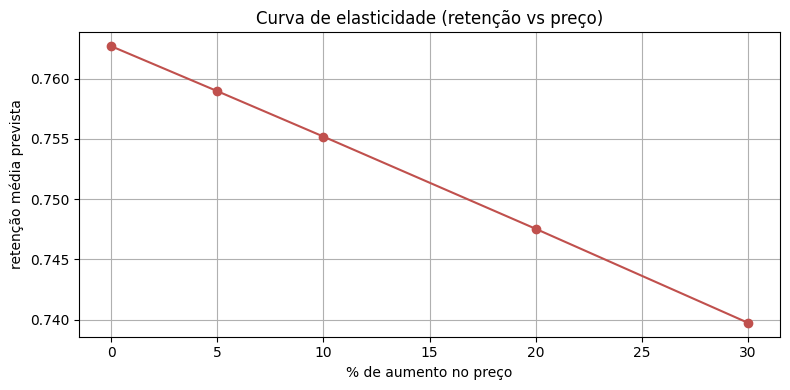

retencao +30%: 0.74 vs base 0.763 -> ELASTICIDADE FRACA (endogeneidade)


In [2]:
q = pd.qcut(obs['Premium'], 5, labels=False)
print('renovacao por quintil de premio:', obs.groupby(q)['renewed'].mean().round(3).to_dict())

ret_feats = RETENTION_NUMERIC + ES_CATEGORICAL
ret = build_retention_model().fit(tr[ret_feats], tr['renewed'])
gbm = build_retention_gbm().fit(tr[ret_feats], tr['renewed'])
auc_glm = roc_auc_score(te['renewed'], ret.predict_proba(te[ret_feats])[:, 1])
auc_gbm = roc_auc_score(te['renewed'], gbm.predict_proba(te[ret_feats])[:, 1])
print('AUC out-of-time: logistica', round(auc_glm, 3), '| GBM', round(auc_gbm, 3))

pcts = [0, 5, 10, 20, 30]
rr = []
for p in pcts:
    t = te.copy(); t['Premium'] = te['Premium'] * (1 + p / 100)
    rr.append(ret.predict_proba(t[ret_feats])[:, 1].mean())
plt.plot(pcts, rr, 'o-', color='#c0504d')
plt.xlabel('% de aumento no preço'); plt.ylabel('retenção média prevista')
plt.title('Curva de elasticidade (retenção vs preço)'); plt.grid(True); plt.tight_layout(); plt.show()
print('retencao +30%:', round(rr[-1], 3), 'vs base', round(rr[0], 3), '-> ELASTICIDADE FRACA (endogeneidade)')

## 2. Custo esperado (o piso de margem)

GBM-Poisson sobre o custo de sinistros **capado** (winsorizado no p99). Trocamos o GLM Tweedie log-link porque os outliers (até ~260k EUR) o faziam **explodir** (previsões de 10^x).

In [3]:
cf = ES_NUMERIC + ES_CATEGORICAL
cap = tr['LossCost'].quantile(0.99)
cost = build_cost_model().fit(tr[cf], tr['LossCost'].clip(upper=cap))
cost_te = np.clip(cost.predict(te[cf]), 1e-6, None)
dev_m = mean_tweedie_deviance(te['LossCost'], cost_te, power=1.5)
dev_b = mean_tweedie_deviance(te['LossCost'], np.full(len(te), tr['LossCost'].clip(upper=cap).mean()), power=1.5)
print(f'custo deviance: modelo {dev_m:.1f} vs naive {dev_b:.1f} ({(dev_b-dev_m)/dev_b*100:+.1f}%)')
print(f'custo previsto {cost_te.mean():.1f} vs real {te["LossCost"].mean():.1f} EUR (calibrado)')

custo deviance: modelo 32.3 vs naive 66.9 (+51.7%)
custo previsto 173.9 vs real 147.1 EUR (calibrado)


## 3. Otimização de prêmio (lucro × retenção)

Para cada apólice, o preço que maximiza **E[lucro] = P(renovar)·(preço − custo)**. Mostramos o ótimo **irrestrito** (cautionary) e o **restrito a ±15%** (crível).

In [4]:
prem = te['Premium']
base_ret = ret.predict_proba(te[ret_feats])[:, 1]
profit_cur = (base_ret * (prem.to_numpy() - cost_te)).sum()

def resumo(r):
    return r['exp_profit'].sum(), r['p_renew'].mean(), r['optimal_price'].mean()

rn = optimize_premium(ret, te[ret_feats].copy(), prem, cost_te, np.round(np.arange(0.70, 1.41, 0.05), 2))
rb = optimize_premium(ret, te[ret_feats].copy(), prem, cost_te, np.round(np.arange(0.85, 1.16, 0.05), 2))
pn, rrn, prn = resumo(rn); pb, rrb, prb = resumo(rb)
pd.DataFrame([
    {'cenario': 'atual', 'lucro_k_EUR': round(profit_cur/1e3), 'retencao': round(base_ret.mean(), 3), 'preco_medio': round(prem.mean())},
    {'cenario': 'otimo IRRESTRITO (red flag)', 'lucro_k_EUR': round(pn/1e3), 'retencao': round(rrn, 3), 'preco_medio': round(prn)},
    {'cenario': 'otimo restrito +-15%', 'lucro_k_EUR': round(pb/1e3), 'retencao': round(rrb, 3), 'preco_medio': round(prb)},
])

,cenario,lucro_k_EUR,retencao,preco_medio
0,atual,3705,0.763,317
1,otimo IRRESTRITO (red flag),6349,0.732,444
2,otimo restrito +-15%,4734,0.751,365


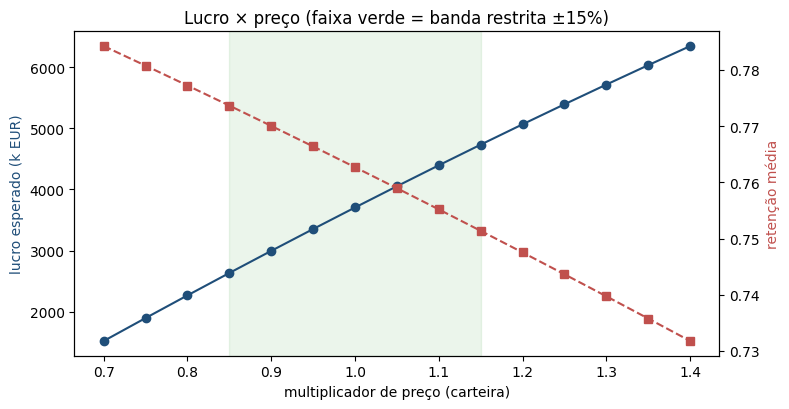

In [5]:
mults = np.round(np.arange(0.70, 1.41, 0.05), 2)
tp, mr = [], []
for m in mults:
    X = te[ret_feats].copy(); X['Premium'] = prem * m
    p = ret.predict_proba(X)[:, 1]
    tp.append(float((p * (prem.to_numpy() * m - cost_te)).sum()) / 1e3)
    mr.append(float(p.mean()))
fig, ax1 = plt.subplots(figsize=(8, 4.2))
ax1.plot(mults, tp, 'o-', color='#1f4e79'); ax1.set_xlabel('multiplicador de preço (carteira)')
ax1.set_ylabel('lucro esperado (k EUR)', color='#1f4e79')
ax1.axvspan(0.85, 1.15, color='green', alpha=0.08)
ax2 = ax1.twinx(); ax2.plot(mults, mr, 's--', color='#c0504d'); ax2.set_ylabel('retenção média', color='#c0504d')
ax1.set_title('Lucro × preço (faixa verde = banda restrita ±15%)'); plt.tight_layout(); plt.show()

## 4. Conclusões da v2

- **Método completo:** custo (GBM-Poisson) + retenção (logística/GBM, AUC ~0,66/0,70 out-of-time) + otimização sob trade-off lucro×retenção, com **validação temporal** real.
- **Achado honesto:** a elasticidade estimada é **fraca** (endogeneidade) → o ótimo *irrestrito* sobe ao teto (+71%), o que é um **red flag**, não um resultado. O restrito ±15% (+28%) é o crível.
- **O que produção exigiria:** um **experimento de preço** (ou variável instrumental) para identificar a elasticidade causal. Reconhecer isso é o ponto sênior do projeto.

*Próximos:* **v3** MLOps (MLflow/Docker/drift/CI) · **v4** score territorial BR.